In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('loan_data.csv')

In [3]:
df.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


In [4]:
df.describe()

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
count,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9.578000e+03,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000
mean,0.804970,0.122640,319.089413,10.932117,12.606679,710.846314,4560.767197,1.691396e+04,46.799236,1.577469,0.163708,0.062122,0.160054
std,0.396245,0.026847,207.071301,0.614813,6.883970,37.970537,2496.930377,3.375619e+04,29.014417,2.200245,0.546215,0.262126,0.366676
min,0.000000,0.060000,15.670000,7.547502,0.000000,612.000000,178.958333,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.103900,163.770000,10.558414,7.212500,682.000000,2820.000000,3.187000e+03,22.600000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.122100,268.950000,10.928884,12.665000,707.000000,4139.958333,8.596000e+03,46.300000,1.000000,0.000000,0.000000,0.000000
75%,1.000000,0.140700,432.762500,11.291293,17.950000,737.000000,5730.000000,1.824950e+04,70.900000,2.000000,0.000000,0.000000,0.000000
max,1.000000,0.216400,940.140000,14.528354,29.960000,827.000000,17639.958330,1.207359e+06,119.000000,33.000000,13.000000,5.000000,1.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB


In [6]:
df.isnull().sum().sort_values(ascending=False)

credit.policy        0
purpose              0
int.rate             0
installment          0
log.annual.inc       0
dti                  0
fico                 0
days.with.cr.line    0
revol.bal            0
revol.util           0
inq.last.6mths       0
delinq.2yrs          0
pub.rec              0
not.fully.paid       0
dtype: int64

In [7]:
for col in df.columns:
    print(df[col].value_counts())

1    7710
0    1868
Name: credit.policy, dtype: int64
debt_consolidation    3957
all_other             2331
credit_card           1262
home_improvement       629
small_business         619
major_purchase         437
educational            343
Name: purpose, dtype: int64
0.1253    354
0.0894    299
0.1183    243
0.1218    215
0.0963    210
         ... 
0.2016      1
0.1683      1
0.1778      1
0.1756      1
0.1867      1
Name: int.rate, Length: 249, dtype: int64
317.72    41
316.11    34
319.47    29
381.26    27
662.68    27
          ..
97.53      1
76.26      1
150.84     1
158.99     1
853.43     1
Name: installment, Length: 4788, dtype: int64
11.002100    308
10.819778    248
10.308953    224
10.596635    224
10.714418    221
            ... 
11.217534      1
12.078239      1
10.068451      1
9.621788       1
10.110472      1
Name: log.annual.inc, Length: 1987, dtype: int64
0.00     89
10.00    19
0.60     16
15.10    13
12.00    13
         ..
5.90      1
19.74     1
29.15     1


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['purpose'] = le.fit_transform(df['purpose'])

In [9]:
df['purpose'].value_counts()

2    3957
0    2331
1    1262
4     629
6     619
5     437
3     343
Name: purpose, dtype: int64

Data Visualization

Text(0.5, 0, 'FICO')

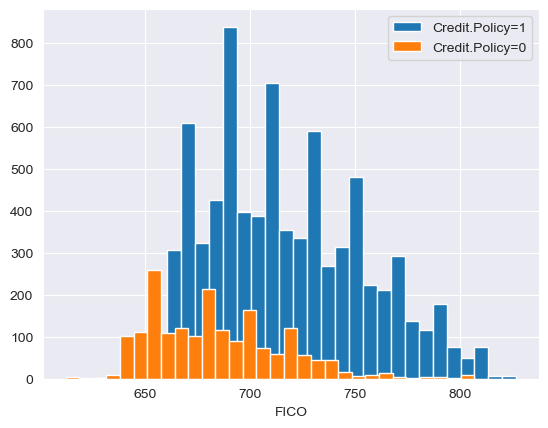

In [12]:
sns.set_style('darkgrid')
plt.hist(df['fico'].loc[df['credit.policy']==1], bins=30, label='Credit.Policy=1')
plt.hist(df['fico'].loc[df['credit.policy']==0], bins=30, label='Credit.Policy=0')
plt.legend()
plt.xlabel('FICO')

Text(0.5, 0, 'FICO')

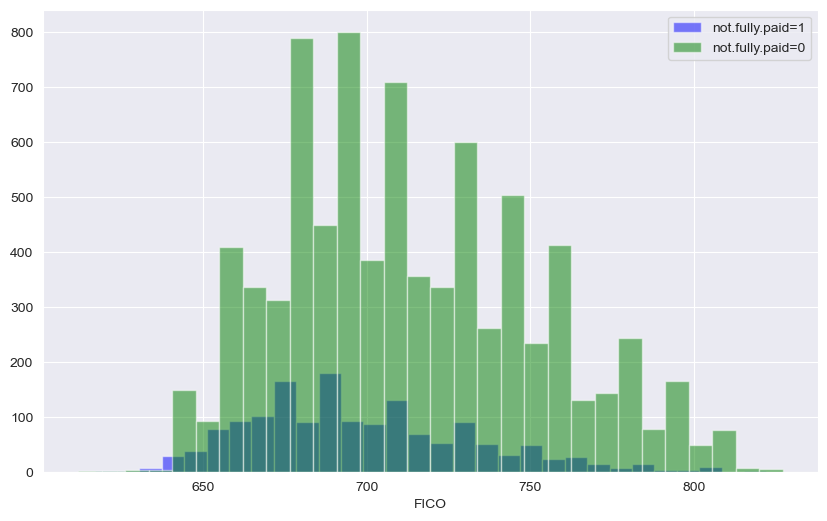

In [13]:
plt.figure(figsize=(10,6))
df[df['not.fully.paid']==1]['fico'].hist(bins=30, alpha=0.5, color='blue', label='not.fully.paid=1')
df[df['not.fully.paid']==0]['fico'].hist(bins=30, alpha=0.5, color='green', label='not.fully.paid=0')
plt.legend()
plt.xlabel('FICO')

<Axes: xlabel='purpose', ylabel='count'>

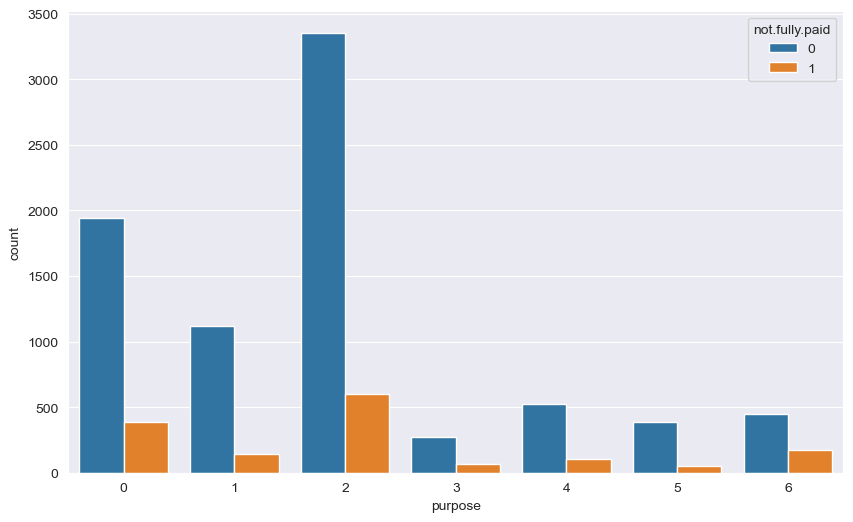

In [14]:
plt.figure(figsize=(10,6))
sns.countplot(x='purpose', hue='not.fully.paid', data=df)

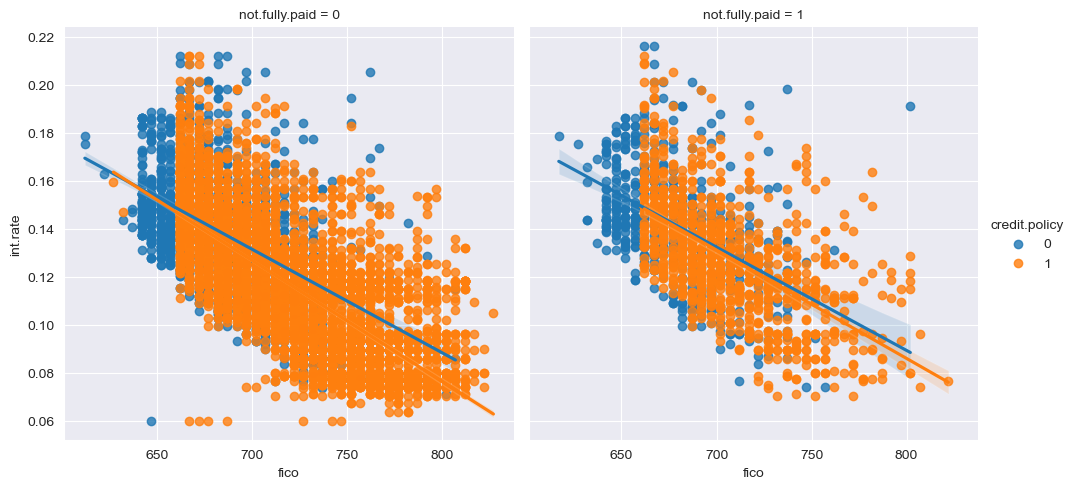

In [17]:
#understanding the relationship between credit.policy and not.fully.paid
sns.lmplot(x="fico",y="int.rate",hue="credit.policy",col="not.fully.paid",data=df)

<Axes: >

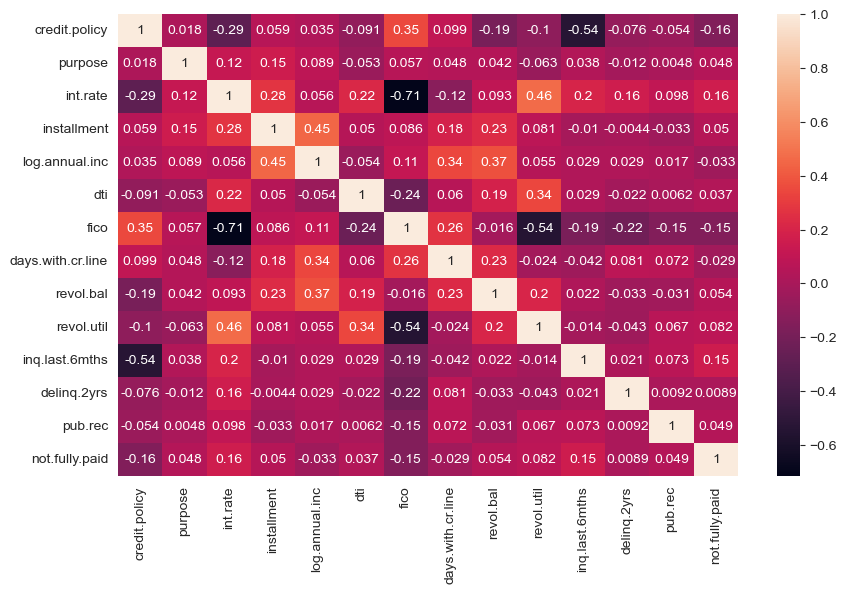

In [18]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(),annot=True)

train-test split

In [19]:
X = df.drop('not.fully.paid', axis=1)
y = df['not.fully.paid']

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=44, shuffle =True)

apply smote

In [21]:
from imblearn.over_sampling import SMOTE 
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

Decision tree

In [22]:
from sklearn.tree import DecisionTreeClassifier

dtree = DecisionTreeClassifier()
dtree.fit(X_resampled, y_resampled)

DecisionTreeClassifier()

In [ ]:
y_pred_train = dtree.predict(X_train)
y_pred_test = dtree.predict(X_test)


In [24]:
from sklearn.metrics import accuracy_score
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)
print('Train Accuracy:', train_accuracy)
print('Test Accuracy:', test_accuracy)

Train Accuracy: 1.0
Test Accuracy: 1.0


[[1618    0]
 [   0  298]]


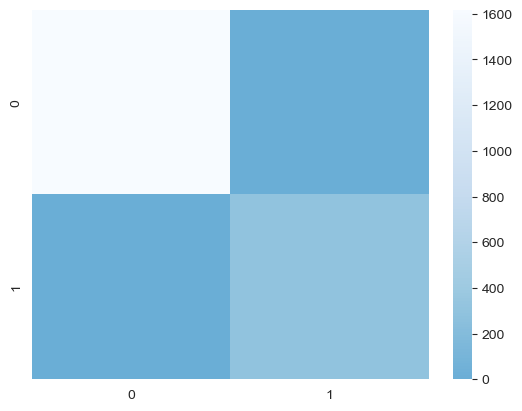

In [26]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_test)
print(cm)
# drawing confusion matrix
sns.heatmap(cm, center = True,cmap='Blues_r')
plt.show()

In [27]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1618
           1       1.00      1.00      1.00       298

    accuracy                           1.00      1916
   macro avg       1.00      1.00      1.00      1916
weighted avg       1.00      1.00      1.00      1916



Random Forest Classifier

In [28]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_resampled, y_resampled)
y_pred_train = rf.predict(X_train)
y_pred_test = rf.predict(X_test)

train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)
print('Train Accuracy:', train_accuracy)
print('Test Accuracy:', test_accuracy)

Train Accuracy: 1.0
Test Accuracy: 1.0


[[1618    0]
 [   0  298]]


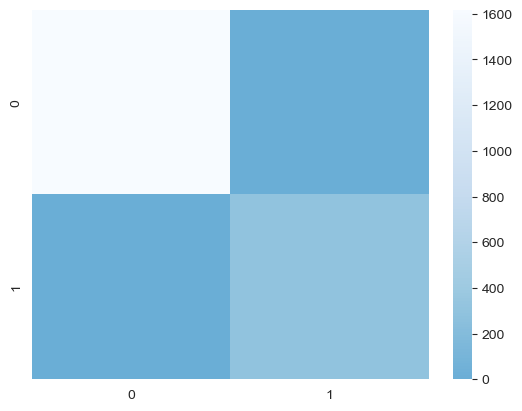

In [29]:
cm = confusion_matrix(y_test, y_pred_test)
print(cm)

sns.heatmap(cm, center = True,cmap='Blues_r')
plt.show()

In [30]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1618
           1       1.00      1.00      1.00       298

    accuracy                           1.00      1916
   macro avg       1.00      1.00      1.00      1916
weighted avg       1.00      1.00      1.00      1916



Gradient boosting

In [32]:
!pip install xgboost

                                              0.0/101.7 MB ? eta -:--:--
                                            0.0/101.7 MB 640.0 kB/s eta 0:02:39
                                            0.1/101.7 MB 653.6 kB/s eta 0:02:36
                                            0.1/101.7 MB 944.1 kB/s eta 0:01:48
                                              0.2/101.7 MB 1.3 MB/s eta 0:01:18
                                              0.4/101.7 MB 1.6 MB/s eta 0:01:03
                                              0.5/101.7 MB 1.9 MB/s eta 0:00:55
                                              0.7/101.7 MB 2.1 MB/s eta 0:00:49
                                              0.9/101.7 MB 2.3 MB/s eta 0:00:43
                                              1.1/101.7 MB 2.5 MB/s eta 0:00:40
                                              1.3/101.7 MB 2.7 MB/s eta 0:00:38
                                              1.4/101.7 MB 2.7 MB/s eta 0:00:37
                                              1

ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\ProgramData\\anaconda3\\Lib\\site-packages\\xgboost'
Consider using the `--user` option or check the permissions.



In [35]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()
gb.fit(X_resampled, y_resampled)
y_pred_train = gb.predict(X_train)
y_pred_test = gb.predict(X_test)

train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)
print('Train Accuracy:', train_accuracy)
print('Test Accuracy:', test_accuracy)  

Train Accuracy: 0.7531975985382406
Test Accuracy: 0.7599164926931107


[[1335  283]
 [ 177  121]]


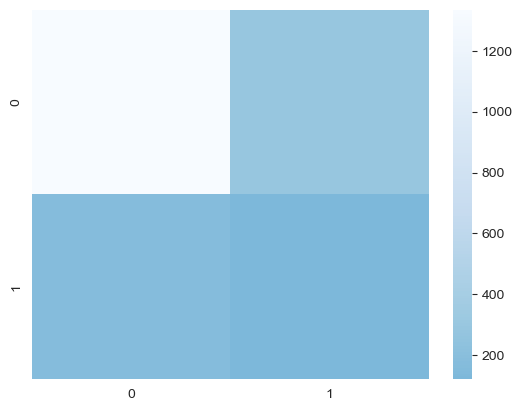

In [36]:
cm = confusion_matrix(y_test, y_pred_test)
print(cm)

sns.heatmap(cm, center = True,cmap='Blues_r')
plt.show()

In [37]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.88      0.83      0.85      1618
           1       0.30      0.41      0.34       298

    accuracy                           0.76      1916
   macro avg       0.59      0.62      0.60      1916
weighted avg       0.79      0.76      0.77      1916

